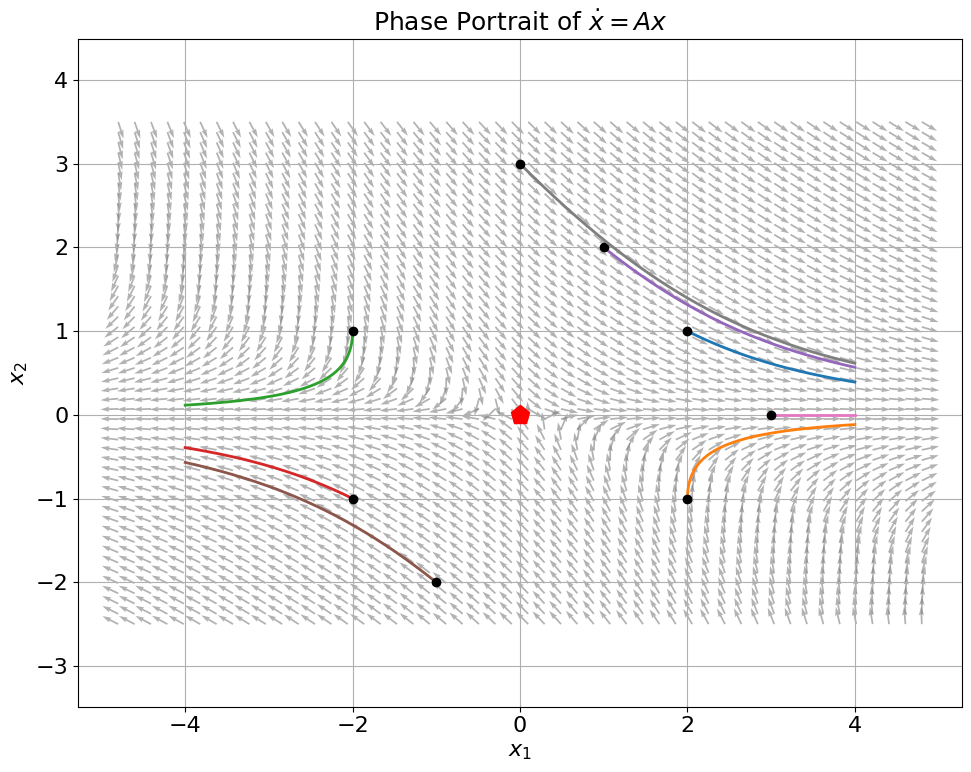

Matrix A:
[[ 1  2]
 [ 0 -2]]

Eigenvalues of A: [ 1. -2.]


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System definition
# Upper-triangular matrix
A = np.array([[-1, 2],
              [0, -2]])

# A = np.array([[1, 2],
#               [0, -2]])

# Linear system: dx/dt = A x
def f(t, x):
    return A @ x

# Simulation parameters
Tmax = 10
tspan = (0, Tmax)

# Define the fixed simulation box boundaries for event detection
# These values will not be overwritten later for plotting limits
fixed_x1_min = -4
fixed_x1_max = 4
fixed_x2_min = -4
fixed_x2_max = 4

# Define individual event functions for each boundary
# Each function must return a scalar value. When this value is zero, an event occurs.

# Event for hitting the left boundary (x[0] <= fixed_x1_min)
def event_left_boundary(t, x):
    return x[0] - fixed_x1_min
event_left_boundary.terminal = True
event_left_boundary.direction = -1 # Detect crossing from positive to negative (leaving left side)

# Event for hitting the right boundary (x[0] >= fixed_x1_max)
def event_right_boundary(t, x):
    return x[0] - fixed_x1_max
event_right_boundary.terminal = True
event_right_boundary.direction = 1 # Detect crossing from negative to positive (leaving right side)

# Event for hitting the bottom boundary (x[1] <= fixed_x2_min)
def event_bottom_boundary(t, x):
    return x[1] - fixed_x2_min
event_bottom_boundary.terminal = True
event_bottom_boundary.direction = -1 # Detect crossing from positive to negative (leaving bottom side)

# Event for hitting the top boundary (x[1] >= fixed_x2_max)
def event_top_boundary(t, x):
    return x[1] - fixed_x2_max
event_top_boundary.terminal = True
event_top_boundary.direction = 1 # Detect crossing from negative to positive (leaving top side)

# Collect all event functions into a list
all_terminal_events = [
    event_left_boundary,
    event_right_boundary,
    event_bottom_boundary,
    event_top_boundary
]

# Initial conditions
X0 = np.array([[2, 1],
               [2, -1],
               [-2, 1],
               [-2, -1],
               [1, 2],
               [-1, -2],
               [3, 0],
               [0, 3]])

# First: simulate all trajectories
Nsim = X0.shape[0]

T = []
X = []

# Number of points for plotting each trajectory
num_plot_points = 200

for i in range(Nsim):
    # Select i-th initial condition
    x0 = X0[i, :]

    # Simulate with event handling
    # Use the list of event functions
    sol = solve_ivp(f, tspan, x0, method='RK45',
                    events=all_terminal_events,
                    dense_output=True)

    # Generate 200 equally spaced points for plotting within the actual simulated time range
    t_plot = np.linspace(sol.t[0], sol.t[-1], num_plot_points)
    x_plot = sol.sol(t_plot).T

    T.append(t_plot)
    X.append(x_plot)

# Determine plotting region from all trajectories
Xall = np.vstack(X)

x1_min = np.min(Xall[:, 0])
x1_max = np.max(Xall[:, 0])
x2_min = np.min(Xall[:, 1])
x2_max = np.max(Xall[:, 1])

# Add some margin
margin = 0.1

dx1 = x1_max - x1_min
dx2 = x2_max - x2_min

x1_min = x1_min - margin * dx1
x1_max = x1_max + margin * dx1
x2_min = x2_min - margin * dx2
x2_max = x2_max + margin * dx2

# Construct vector field grid
Ngrid = 50

x1_grid = np.linspace(x1_min, x1_max, Ngrid)
x2_grid = np.linspace(x2_min, x2_max, Ngrid)
x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)

# Evaluate vector field at every grid point
u = np.zeros(x1_grid.shape)
v = np.zeros(x2_grid.shape)

for i in range(x1_grid.shape[0]):
    for j in range(x1_grid.shape[1]):
        x_val = np.array([x1_grid[i, j], x2_grid[i, j]]) # Renamed x to x_val to avoid confusion
        dx = A @ x_val
        u[i, j] = dx[0]
        v[i, j] = dx[1]

# Normalize arrows so that the vector field direction
# is emphasized rather than the magnitude
magnitude = np.sqrt(u**2 + v**2)
u = u / (magnitude + 1e-10)
v = v / (magnitude + 1e-10)

# Plot
plt.figure(figsize=(10, 8))
plt.grid(True)
plt.box(True)

# Plot vector field first, so trajectories appear on top
plt.quiver(x1_grid, x2_grid, u, v, scale=50, width=0.002,
           color='gray', alpha=0.6)

# Plot trajectories
for i in range(Nsim):
    x = X[i]
    x0 = X0[i, :]

    plt.plot(x[:, 0], x[:, 1], linewidth=2)

    # Mark initial condition
    plt.plot(x0[0], x0[1], 'ko', markersize=6)

# Mark equilibrium
plt.plot(0, 0, 'rp', markersize=14, markerfacecolor='r')

plt.xlabel('$x_1$', fontsize=16)
plt.ylabel('$x_2$', fontsize=16)
plt.title(r'Phase Portrait of $\dot{x}=Ax$', fontsize=18) # Used raw string for LaTeX escape sequences

plt.xlim([x1_min, x1_max])
plt.ylim([x2_min, x2_max])
plt.axis('equal')

plt.tight_layout()
plt.show()

# Print matrix A for reference
print("Matrix A:")
print(A)
print("\nEigenvalues of A:", np.linalg.eigvals(A))

# System Analysis: $\dot{x} = f(x)$

We analyze the two-dimensional system:

$$
\begin{cases}
\dot{x}_1 = x_2 - x_1^2 \\
\dot{x}_2 = x_1 - x_2
\end{cases}
$$

---

## 1. Fixed Points

Fixed points satisfy $\dot{x} = 0$, i.e.:

$$
x_2 - x_1^2 = 0 \quad \text{and} \quad x_1 - x_2 = 0
$$

From the second equation, $x_2 = x_1$. Substituting into the first:

$$
x_1 - x_1^2 = 0 \quad \Rightarrow \quad x_1(1 - x_1) = 0
$$

Thus:

$$
x_1 = 0 \quad \text{or} \quad x_1 = 1
$$

So the fixed points are:

$$
(0, 0) \quad \text{and} \quad (1, 1)
$$

---

## 2. Stability via Jacobian

The Jacobian matrix of $f(x)$ is:

$$
J(x_1, x_2) =
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2}
\end{bmatrix}
=
\begin{bmatrix}
-2x_1 & 1 \\
1 & -1
\end{bmatrix}
$$

### At $(0, 0)$:

$$
J(0,0) =
\begin{bmatrix}
0 & 1 \\
1 & -1
\end{bmatrix}
$$

Eigenvalues: solve $\det(J - \lambda I) = 0$:

$$
\det\begin{bmatrix}
-\lambda & 1 \\
1 & -1-\lambda
\end{bmatrix}
= \lambda^2 + \lambda - 1 = 0
$$

$$
\lambda = \frac{-1 \pm \sqrt{1 + 4}}{2} = \frac{-1 \pm \sqrt{5}}{2}
$$

So:

$$
\lambda_1 \approx 0.618 > 0, \quad \lambda_2 \approx -1.618 < 0
$$

So, $(0,0)$ is a **saddle point** (unstable).

---

### At $(1, 1)$:

$$
J(1,1) =
\begin{bmatrix}
-2 & 1 \\
1 & -1
\end{bmatrix}
$$

Eigenvalues:

$$
\det\begin{bmatrix}
-2-\lambda & 1 \\
1 & -1-\lambda
\end{bmatrix}
= ( -2-\lambda)(-1-\lambda) - 1 = \lambda^2 + 3\lambda + 1 = 0
$$

$$
\lambda = \frac{-3 \pm \sqrt{9 - 4}}{2} = \frac{-3 \pm \sqrt{5}}{2}
$$

Both eigenvalues are negative:

$$
\lambda_1 \approx -0.382 < 0, \quad \lambda_2 \approx -2.618 < 0
$$

So, $(1,1)$ is a **stable node** (asymptotically stable).

---

| Fixed Point | Eigenvalues        | Stability       |
|-------------|-------------------|-----------------|
| $(0,0)$     | $0.618, -1.618$   | Saddle (unstable) |
| $(1,1)$     | $-0.382, -2.618$  | Stable node     |

---

This tells us that trajectories near $(1,1)$ will converge to it, while near $(0,0)$ they will be repelled along one direction and attracted along another — typical saddle behavior.

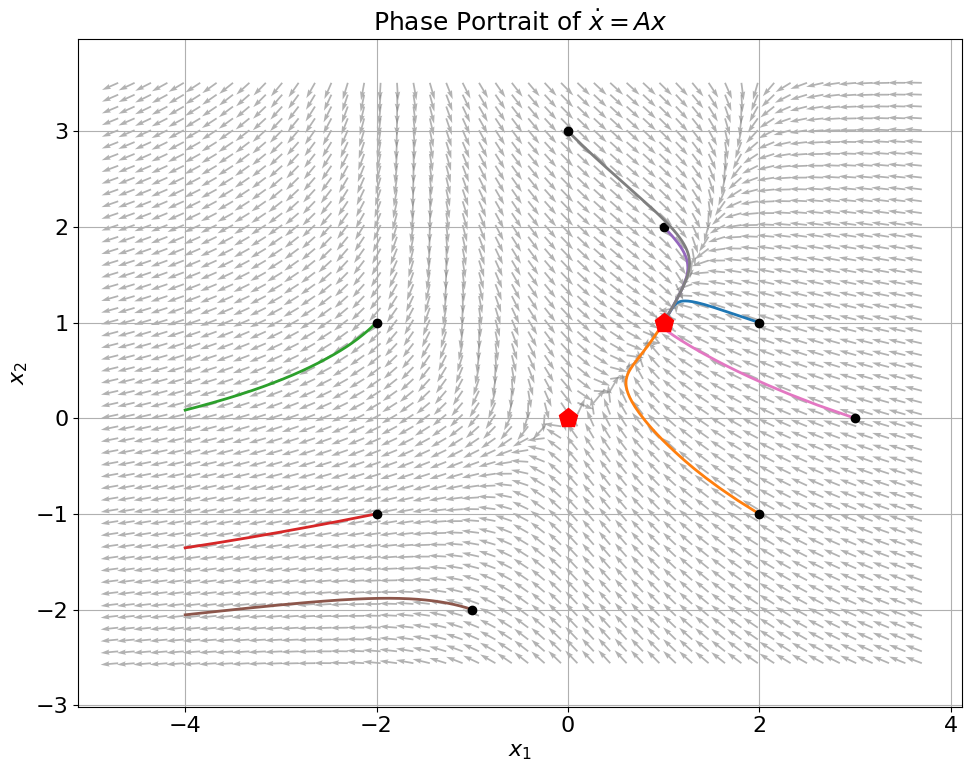

Matrix A:
[[ 1  2]
 [ 0 -2]]

Eigenvalues of A: [ 1. -2.]


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System definition
# Upper-triangular Hurwitz matrix

def f(t, x):
    return np.array([x[1] - x[0] ** 2, x[0] - x[1]])

# Simulation parameters
Tmax = 10
tspan = (0, Tmax)

# Define the fixed simulation box boundaries for event detection
# These values will not be overwritten later for plotting limits
fixed_x1_min = -4
fixed_x1_max = 4
fixed_x2_min = -4
fixed_x2_max = 4

# Define individual event functions for each boundary
# Each function must return a scalar value. When this value is zero, an event occurs.

# Event for hitting the left boundary (x[0] <= fixed_x1_min)
def event_left_boundary(t, x):
    return x[0] - fixed_x1_min
event_left_boundary.terminal = True
event_left_boundary.direction = -1 # Detect crossing from positive to negative (leaving left side)

# Event for hitting the right boundary (x[0] >= fixed_x1_max)
def event_right_boundary(t, x):
    return x[0] - fixed_x1_max
event_right_boundary.terminal = True
event_right_boundary.direction = 1 # Detect crossing from negative to positive (leaving right side)

# Event for hitting the bottom boundary (x[1] <= fixed_x2_min)
def event_bottom_boundary(t, x):
    return x[1] - fixed_x2_min
event_bottom_boundary.terminal = True
event_bottom_boundary.direction = -1 # Detect crossing from positive to negative (leaving bottom side)

# Event for hitting the top boundary (x[1] >= fixed_x2_max)
def event_top_boundary(t, x):
    return x[1] - fixed_x2_max
event_top_boundary.terminal = True
event_top_boundary.direction = 1 # Detect crossing from negative to positive (leaving top side)

# Collect all event functions into a list
all_terminal_events = [
    event_left_boundary,
    event_right_boundary,
    event_bottom_boundary,
    event_top_boundary
]

# Initial conditions
X0 = np.array([[2, 1],
               [2, -1],
               [-2, 1],
               [-2, -1],
               [1, 2],
               [-1, -2],
               [3, 0],
               [0, 3]])

# First: simulate all trajectories
Nsim = X0.shape[0]

T = []
X = []

# Number of points for plotting each trajectory
num_plot_points = 200

for i in range(Nsim):
    # Select i-th initial condition
    x0 = X0[i, :]

    # Simulate with event handling
    # Use the list of event functions
    sol = solve_ivp(f, tspan, x0, method='RK45',
                    events=all_terminal_events,
                    dense_output=True)

    # Generate 200 equally spaced points for plotting within the actual simulated time range
    t_plot = np.linspace(sol.t[0], sol.t[-1], num_plot_points)
    x_plot = sol.sol(t_plot).T

    T.append(t_plot)
    X.append(x_plot)

# Determine plotting region from all trajectories
Xall = np.vstack(X)

x1_min = np.min(Xall[:, 0])
x1_max = np.max(Xall[:, 0])
x2_min = np.min(Xall[:, 1])
x2_max = np.max(Xall[:, 1])

# Add some margin
margin = 0.1

dx1 = x1_max - x1_min
dx2 = x2_max - x2_min

x1_min = x1_min - margin * dx1
x1_max = x1_max + margin * dx1
x2_min = x2_min - margin * dx2
x2_max = x2_max + margin * dx2

# Construct vector field grid
Ngrid = 50

x1_grid = np.linspace(x1_min, x1_max, Ngrid)
x2_grid = np.linspace(x2_min, x2_max, Ngrid)
x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)

# Evaluate vector field at every grid point
u = np.zeros(x1_grid.shape)
v = np.zeros(x2_grid.shape)

for i in range(x1_grid.shape[0]):
    for j in range(x1_grid.shape[1]):
        x_val = np.array([x1_grid[i, j], x2_grid[i, j]]) # Renamed x to x_val to avoid confusion
        dx = f(0, x_val)
        u[i, j] = dx[0]
        v[i, j] = dx[1]

# Normalize arrows so that the vector field direction
# is emphasized rather than the magnitude
magnitude = np.sqrt(u**2 + v**2)
u = u / (magnitude + 1e-10)
v = v / (magnitude + 1e-10)

# Plot
plt.figure(figsize=(10, 8))
plt.grid(True)
plt.box(True)

# Plot vector field first, so trajectories appear on top
plt.quiver(x1_grid, x2_grid, u, v, scale=50, width=0.002,
           color='gray', alpha=0.6)

# Plot trajectories
for i in range(Nsim):
    x = X[i]
    x0 = X0[i, :]

    plt.plot(x[:, 0], x[:, 1], linewidth=2)

    # Mark initial condition
    plt.plot(x0[0], x0[1], 'ko', markersize=6)

# Mark equilibrium
plt.plot(0, 0, 'rp', markersize=14, markerfacecolor='r')
plt.plot(1, 1, 'rp', markersize=14, markerfacecolor='r')

plt.xlabel('$x_1$', fontsize=16)
plt.ylabel('$x_2$', fontsize=16)
plt.title(r'Phase Portrait of $\dot{x}=Ax$', fontsize=18) # Used raw string for LaTeX escape sequences

plt.xlim([x1_min, x1_max])
plt.ylim([x2_min, x2_max])
plt.axis('equal')

plt.tight_layout()
plt.show()

# Print matrix A for reference
print("Matrix A:")
print(A)
print("\nEigenvalues of A:", np.linalg.eigvals(A))

# Cart-Pole Stabilization with LQR

Consider a classical **cart-pole system**, consisting of a cart that moves horizontally and a pendulum attached to the cart through a frictionless pivot.

The system state is

$$
x =
\begin{bmatrix}
p & \dot p & \theta & \dot{\theta}
\end{bmatrix}^T,
$$

where:

* $p$ is the horizontal position of the cart,
* $\dot p$ is the cart velocity,
* $\theta$ is the pole angle measured from the vertical upright position,
* $\dot\theta$ is the angular velocity.

The upright equilibrium corresponds to

$$
x^\star = 0,
$$

that is, the cart is stationary and the pole is perfectly vertical.

## Nonlinear and Linear Models

The full dynamics of the cart-pole system are nonlinear due to the trigonometric terms

$$
\sin(\theta), \qquad \cos(\theta),
$$

as well as the coupling between the cart and pole motion.

We also construct a linear approximation of the system around the upright equilibrium,

$$
\dot x = Ax + Bu.
$$

This linear model is only expected to accurately represent the nonlinear system for sufficiently small deviations from the equilibrium.

## LQR Controller

An LQR controller is designed using the linearized model. The controller has the state-feedback form

$$
u = -Kx,
$$

where the gain $K$ minimizes the quadratic cost

$$
J =
\int_0^\infty
\left(
x^TQx + u^TRu
\right)dt.
$$

The matrices $Q \succeq 0$ and $R \succ 0$ determine the relative penalty on state deviations and control effort.

## Simulation

The same LQR controller is applied to both:

1. the closed-loop linearized system;
2. the full nonlinear cart-pole system.

Both systems are simulated from the same initial condition, allowing us to compare the predictions of the linear model with the behavior of the true nonlinear system.

To avoid numerical trajectories growing to extremely large values, the simulations include event-based safeguards that terminate the integration if the state leaves a prescribed region.

LQR gain:
[[-10.         -11.66080335 -72.58141118 -18.87192809]]

Linear simulation reached Tfinal.

Nonlinear simulation reached Tfinal.


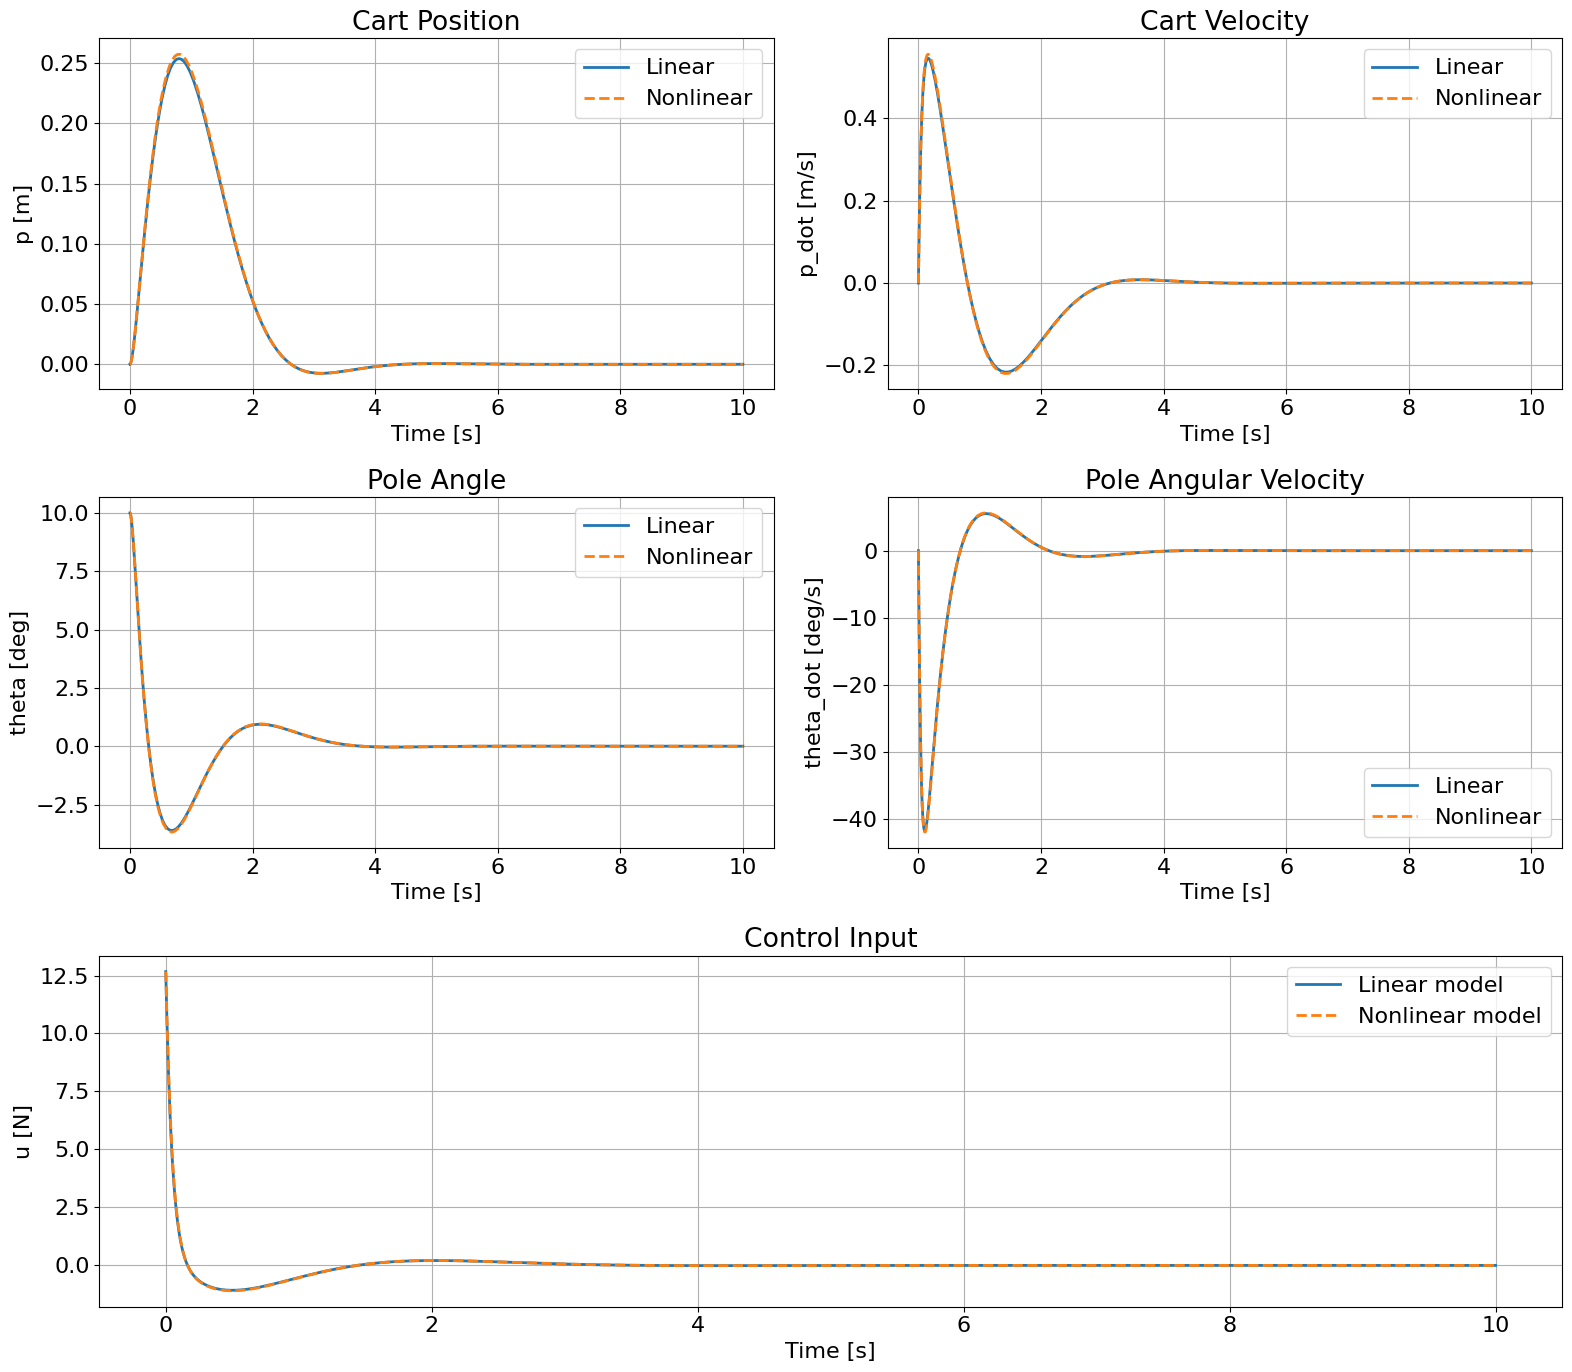

In [21]:
# ================================================================
# CART-POLE: LINEAR LQR CONTROL VS FULL NONLINEAR SIMULATION
#
# State:
#
#     x = [ p ; p_dot ; theta ; theta_dot ]
#
# where:
#
#     p     = cart position
#     theta = pole angle measured from upright position
#
# theta = 0 corresponds to the upright equilibrium.
#
# ================================================================


import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are


# ================================================================
# 1. PARAMETERS
# ================================================================

M = 1.0        # Cart mass [kg]
m = 0.1        # Pole mass [kg]
l = 0.5        # Distance from pivot to pole center of mass [m]
g = 9.81       # Gravity [m/s^2]


# ================================================================
# 2. NONLINEAR MODEL
#
# Equations:
#
# (M+m) p_ddot + m*l*cos(theta)*theta_ddot
#      - m*l*sin(theta)*theta_dot^2 = u
#
# l*theta_ddot + cos(theta)*p_ddot
#      - g*sin(theta) = 0
#
# theta = 0 is upright.
# ================================================================

def cartpole_nonlinear(t, x, K, M, m, l, g):

    # States

    p         = x[0]
    p_dot     = x[1]
    theta     = x[2]
    theta_dot = x[3]


    # ------------------------------------------------------------
    # State feedback controller
    #
    # u = -K*x
    # ------------------------------------------------------------

    u = (-K @ x).item() # Extract scalar value from the (1,) array


    # ------------------------------------------------------------
    # Solve nonlinear equations
    #
    # [ M+m,        m*l*cos(theta) ] [ p_ddot     ]
    # [ cos(theta), l              ] [ theta_ddot ]
    #
    # =
    #
    # [ u + m*l*sin(theta)*theta_dot^2 ]
    # [ g*sin(theta)                   ]
    # ------------------------------------------------------------

    MassMatrix = np.array([
        [M + m,              m * l * np.cos(theta)],
        [np.cos(theta),      l]
    ])

    rhs = np.array([
        u + m * l * np.sin(theta) * theta_dot**2,
        g * np.sin(theta)
    ])

    accelerations = np.linalg.solve(MassMatrix, rhs)

    p_ddot     = accelerations[0]
    theta_ddot = accelerations[1]


    # ------------------------------------------------------------
    # State derivative
    # ------------------------------------------------------------

    dx = np.array([
        p_dot,
        p_ddot,
        theta_dot,
        theta_ddot
    ])

    return dx


# ================================================================
# 3. LINEARIZATION AROUND THE UPRIGHT EQUILIBRIUM
#
# Equilibrium:
#
#     p = 0
#     p_dot = 0
#     theta = 0
#     theta_dot = 0
#
# x_dot = A*x + B*u
# ================================================================

A = np.array([
    [0, 1,              0,              0],
    [0, 0,       -m*g/M,              0],
    [0, 0,              0,              1],
    [0, 0,  g*(M+m)/(M*l),             0]
], dtype=float)

B = np.array([
    [0],
    [1/M],
    [0],
    [-1/(M*l)]
], dtype=float)


# ================================================================
# 4. LQR CONTROLLER DESIGN
#
# u = -K*x
#
# Solve the continuous-time algebraic Riccati equation:
#
# A'P + P*A - P*B*R^(-1)*B'*P + Q = 0
#
# K = R^(-1) B' P
# ================================================================

Q = np.diag([
    10,    # cart position
     1,    # cart velocity
    10,    # pole angle
    10     # pole angular velocity
])

R = np.array([[0.1]])


# Solve continuous-time algebraic Riccati equation

P = solve_continuous_are(A, B, Q, R)


# Compute LQR gain

K = np.linalg.solve(R, B.T @ P)


print("LQR gain:")
print(K)


# ================================================================
# 5. CLOSED-LOOP LINEAR MODEL
#
# x_dot = (A - B*K)x
# ================================================================

Acl = A - B @ K


# ================================================================
# 6. SIMULATION SETTINGS
# ================================================================

Tfinal = 10.0


# Same initial condition for both models

x0 = np.array([
    0.0,                    # cart position
    0.0,                    # cart velocity
    np.deg2rad(10),         # pole angle
    0.0                     # angular velocity
])


# Alternative initial condition

# x0 = np.array([
#     10.0,                 # cart position
#     2.0,                  # cart velocity
#     np.deg2rad(70),       # pole angle
#     -5.0                  # angular velocity
# ])


# ================================================================
# SIMULATION SAFEGUARDS
#
# Stop simulation when the state leaves this box:
#
#     |p|         <= p_max
#     |p_dot|     <= p_dot_max
#     |theta|     <= theta_max
#     |theta_dot| <= theta_dot_max
# ================================================================

p_max         = 5.0
p_dot_max     = 20.0
theta_max     = np.deg2rad(90)
theta_dot_max = np.deg2rad(720)


# ================================================================
# EVENT FUNCTIONS
#
# scipy.solve_ivp requires one event function for each boundary.
#
# Each event returns:
#
#     positive value  -> inside the allowed region
#     zero            -> boundary reached
#     negative value  -> outside
#
# terminal = True stops the simulation.
# ================================================================

def event_p(t, x):
    return p_max - abs(x[0])

event_p.terminal = True
event_p.direction = 0


def event_p_dot(t, x):
    return p_dot_max - abs(x[1])

event_p_dot.terminal = True
event_p_dot.direction = 0


def event_theta(t, x):
    return theta_max - abs(x[2])

event_theta.terminal = True
event_theta.direction = 0


def event_theta_dot(t, x):
    return theta_dot_max - abs(x[3])

event_theta_dot.terminal = True
event_theta_dot.direction = 0


events = [
    event_p,
    event_p_dot,
    event_theta,
    event_theta_dot
]


# ================================================================
# 7. SIMULATE LINEAR CLOSED-LOOP SYSTEM
# ================================================================

def linear_dynamics(t, x):
    return Acl @ x


sol_lin = solve_ivp(
    linear_dynamics,
    [0, Tfinal],
    x0,
    events=events,
    rtol=1e-7,
    atol=1e-9
)


t_lin = sol_lin.t
x_lin = sol_lin.y.T


# ================================================================
# 8. SIMULATE NONLINEAR CLOSED-LOOP SYSTEM
# ================================================================

sol_nonlin = solve_ivp(
    lambda t, x: cartpole_nonlinear(
        t, x, K, M, m, l, g
    ),
    [0, Tfinal],
    x0,
    events=events,
    rtol=1e-7,
    atol=1e-9
)


t_nonlin = sol_nonlin.t
x_nonlin = sol_nonlin.y.T


# ================================================================
# 9. REPORT TERMINATION
# ================================================================

event_names = [
    "cart position bound exceeded",
    "cart velocity bound exceeded",
    "pole angle bound exceeded",
    "pole angular velocity bound exceeded"
]


def report_termination(solution, name):

    terminated = False

    for i, event_times in enumerate(solution.t_events):

        if len(event_times) > 0:

            print()
            print(f"{name} simulation terminated early.")
            print(f"Time: {event_times[0]:.4f} s")
            print(f"Reason: {event_names[i]}")

            terminated = True
            break

    if not terminated:

        print()
        print(f"{name} simulation reached Tfinal.")


report_termination(sol_lin, "Linear")
report_termination(sol_nonlin, "Nonlinear")


# ================================================================
# 10. COMPUTE CONTROL INPUTS
# ================================================================

# Since x_lin has shape (N,4) and K has shape (1,4),
# this computes u(t) = -K*x(t).

u_lin = -(x_lin @ K.T).flatten()

u_nonlin = -(x_nonlin @ K.T).flatten()


# ================================================================
# 11. PLOTS
# ================================================================

plt.rcParams.update({
    'font.size': 16
})


fig, axs = plt.subplots(
    3,
    2,
    figsize=(16, 14)
)


# ------------------------------------------------
# Cart position
# ------------------------------------------------

ax = axs[0, 0]

ax.plot(
    t_lin,
    x_lin[:, 0],
    linewidth=2,
    label='Linear'
)

ax.plot(
    t_nonlin,
    x_nonlin[:, 0],
    '--',
    linewidth=2,
    label='Nonlinear'
)

ax.grid(True)
ax.set_xlabel('Time [s]')
ax.set_ylabel('p [m]')
ax.set_title('Cart Position')
ax.legend()


# ------------------------------------------------
# Cart velocity
# ------------------------------------------------

ax = axs[0, 1]

ax.plot(
    t_lin,
    x_lin[:, 1],
    linewidth=2,
    label='Linear'
)

ax.plot(
    t_nonlin,
    x_nonlin[:, 1],
    '--',
    linewidth=2,
    label='Nonlinear'
)

ax.grid(True)
ax.set_xlabel('Time [s]')
ax.set_ylabel('p_dot [m/s]')
ax.set_title('Cart Velocity')
ax.legend()


# ------------------------------------------------
# Pole angle
# ------------------------------------------------

ax = axs[1, 0]

ax.plot(
    t_lin,
    np.rad2deg(x_lin[:, 2]),
    linewidth=2,
    label='Linear'
)

ax.plot(
    t_nonlin,
    np.rad2deg(x_nonlin[:, 2]),
    '--',
    linewidth=2,
    label='Nonlinear'
)

ax.grid(True)
ax.set_xlabel('Time [s]')
ax.set_ylabel('theta [deg]')
ax.set_title('Pole Angle')
ax.legend()


# ------------------------------------------------
# Pole angular velocity
# ------------------------------------------------

ax = axs[1, 1]

ax.plot(
    t_lin,
    np.rad2deg(x_lin[:, 3]),
    linewidth=2,
    label='Linear'
)

ax.plot(
    t_nonlin,
    np.rad2deg(x_nonlin[:, 3]),
    '--',
    linewidth=2,
    label='Nonlinear'
)

ax.grid(True)
ax.set_xlabel('Time [s]')
ax.set_ylabel('theta_dot [deg/s]')
ax.set_title('Pole Angular Velocity')
ax.legend()


# ------------------------------------------------
# Control input
# ------------------------------------------------

# Remove the two lower axes and replace them with
# one axis spanning the entire width.

fig.delaxes(axs[2, 0])
fig.delaxes(axs[2, 1])

ax = fig.add_subplot(3, 1, 3)

ax.plot(
    t_lin,
    u_lin,
    linewidth=2,
    label='Linear model'
)

ax.plot(
    t_nonlin,
    u_nonlin,
    '--',
    linewidth=2,
    label='Nonlinear model'
)

ax.grid(True)
ax.set_xlabel('Time [s]')
ax.set_ylabel('u [N]')
ax.set_title('Control Input')
ax.legend()


plt.tight_layout()

plt.show()

In [22]:
# ================================================================
# CART-POLE ANIMATION
#
# Usage:
#
#     animate_cartpole(t_nonlin, x_nonlin, l)
#
# ================================================================

from matplotlib import animation
from IPython.display import HTML


def animate_cartpole(t, x, l, speed=1.0):

    """
    Animate cart-pole motion.

    Parameters
    ----------
    t : array, shape (N,)
        Simulation time.

    x : array, shape (N,4)
        State trajectory:

            x[:,0] = cart position
            x[:,1] = cart velocity
            x[:,2] = pole angle
            x[:,3] = pole angular velocity

        theta = 0 corresponds to the upright position.

    l : float
        Pole length, from pivot to center of mass.

    speed : float
        Animation speed multiplier.
        speed > 1  -> faster
        speed < 1  -> slower
    """


    # ------------------------------------------------------------
    # ANIMATION PARAMETERS
    # ------------------------------------------------------------

    cart_width = 0.8
    cart_height = 0.3

    wheel_radius = 0.08

    # For visualization, make the displayed pole longer than l.
    # The physical model uses l as pivot-to-center-of-mass distance.

    pole_length = 2.0 * l


    # ------------------------------------------------------------
    # FIGURE SETUP
    # ------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5))

    # Determine plotting range

    x_min = np.min(x[:, 0]) - 2
    x_max = np.max(x[:, 0]) + 2

    # Ensure reasonable minimum width

    if x_max - x_min < 6:
        center = 0.5 * (x_min + x_max)
        x_min = center - 3
        x_max = center + 3


    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.6, pole_length + 1.0)

    ax.set_aspect('equal')

    ax.grid(True)

    ax.set_xlabel('Cart position [m]')
    ax.set_ylabel('Height [m]')

    ax.set_title('Cart-Pole Animation')


    # ------------------------------------------------------------
    # GROUND
    # ------------------------------------------------------------

    ground_y = 0

    ax.plot(
        [x_min, x_max],
        [ground_y, ground_y],
        linewidth=2
    )


    # ------------------------------------------------------------
    # CREATE GRAPHICAL OBJECTS
    # ------------------------------------------------------------

    # Cart

    cart = plt.Rectangle(
        (0, 0),
        cart_width,
        cart_height
    )

    ax.add_patch(cart)


    # Wheels

    wheel1 = plt.Circle(
        (0, 0),
        wheel_radius
    )

    wheel2 = plt.Circle(
        (0, 0),
        wheel_radius
    )

    ax.add_patch(wheel1)
    ax.add_patch(wheel2)


    # Pole

    pole, = ax.plot(
        [],
        [],
        linewidth=4
    )


    # Pivot

    pivot, = ax.plot(
        [],
        [],
        'o',
        markersize=8
    )


    # Time text

    time_text = ax.text(
        0.02,
        0.95,
        '',
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top'
    )


    # ------------------------------------------------------------
    # INITIALIZATION
    # ------------------------------------------------------------

    def init():

        cart.set_xy((0, 0))

        pole.set_data([], [])

        pivot.set_data([], [])

        time_text.set_text('')

        return (
            cart,
            wheel1,
            wheel2,
            pole,
            pivot,
            time_text
        )


    # ------------------------------------------------------------
    # UPDATE FUNCTION
    # ------------------------------------------------------------

    def update(frame):

        # Current state

        cart_x = x[frame, 0]
        theta = x[frame, 2]


        # --------------------------------------------------------
        # CART POSITION
        # --------------------------------------------------------

        cart_left = cart_x - cart_width / 2

        cart_bottom = wheel_radius

        cart.set_xy(
            (cart_left, cart_bottom)
        )


        # --------------------------------------------------------
        # WHEELS
        # --------------------------------------------------------

        wheel_y = wheel_radius

        wheel1.center = (
            cart_x - cart_width / 4,
            wheel_y
        )

        wheel2.center = (
            cart_x + cart_width / 4,
            wheel_y
        )


        # --------------------------------------------------------
        # POLE PIVOT
        # --------------------------------------------------------

        pivot_x = cart_x

        pivot_y = cart_bottom + cart_height


        # --------------------------------------------------------
        # POLE ENDPOINT
        #
        # theta = 0 is upright.
        #
        # Therefore:
        #
        #     x_tip = pivot_x + L sin(theta)
        #     y_tip = pivot_y + L cos(theta)
        # --------------------------------------------------------

        pole_x = pivot_x + pole_length * np.sin(theta)

        pole_y = pivot_y + pole_length * np.cos(theta)


        # Update pole

        pole.set_data(
            [pivot_x, pole_x],
            [pivot_y, pole_y]
        )


        # Update pivot

        pivot.set_data(
            [pivot_x],
            [pivot_y]
        )


        # Update time display

        time_text.set_text(
            f'Time = {t[frame]:.2f} s'
        )


        return (
            cart,
            wheel1,
            wheel2,
            pole,
            pivot,
            time_text
        )


    # ------------------------------------------------------------
    # FRAME TIMING
    #
    # Use simulation time differences when possible.
    # ------------------------------------------------------------

    if len(t) > 1:

        dt = np.mean(np.diff(t))

    else:

        dt = 0.05


    interval = 1000 * dt / speed


    # ------------------------------------------------------------
    # CREATE ANIMATION
    # ------------------------------------------------------------

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=len(t),
        init_func=init,
        interval=interval,
        blit=True,
        repeat=True
    )


    plt.close(fig)


    # ------------------------------------------------------------
    # DISPLAY IN GOOGLE COLAB
    # ------------------------------------------------------------

    return HTML(
        anim.to_jshtml()
    )

In [24]:
animate_cartpole(
    t_nonlin,
    x_nonlin,
    l,
    speed=1.0
)